In [1]:
# To turn off Warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Importing the diabetes dataset
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
# Exploratory Data Analysis
df.info()
df.shape
df.columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
# Data Cleaning
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
# Check the features with 0 value
zero_counts = df.eq(0).sum()
print(zero_counts)

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [8]:
# Replace Zero values in important features with median value
df['Glucose'] = df['Glucose'].replace(0, np.median(df['Glucose']))

df['BloodPressure'] = df['BloodPressure'].replace(0, np.median(df['BloodPressure']))

df['SkinThickness'] = df['SkinThickness'].replace(0, np.median(df['SkinThickness']))

df['Insulin'] = df['Insulin'].replace(0, np.median(df['Insulin']))

df['BMI'] = df['BMI'].replace(0, np.median(df['BMI']))

In [9]:
zero_counts = df.eq(0).sum()

print(zero_counts)

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [10]:
# Understanding the correlation between features and Outcome
# Get list of feature columns (excluding target)

feature_columns = [col for col in df.columns if col != 'Outcome']



for feature in feature_columns:

    correlation = df[feature].corr(df["Outcome"])

    print('Correlation for ', feature, ' = ', correlation)

Correlation for  Pregnancies  =  0.22189815303398652
Correlation for  Glucose  =  0.49278240391502615
Correlation for  BloodPressure  =  0.16572291308057632
Correlation for  SkinThickness  =  0.18906541957539372
Correlation for  Insulin  =  0.1484572381068214
Correlation for  BMI  =  0.312249026673271
Correlation for  DiabetesPedigreeFunction  =  0.17384406565295973
Correlation for  Age  =  0.23835598302719768


<Axes: >

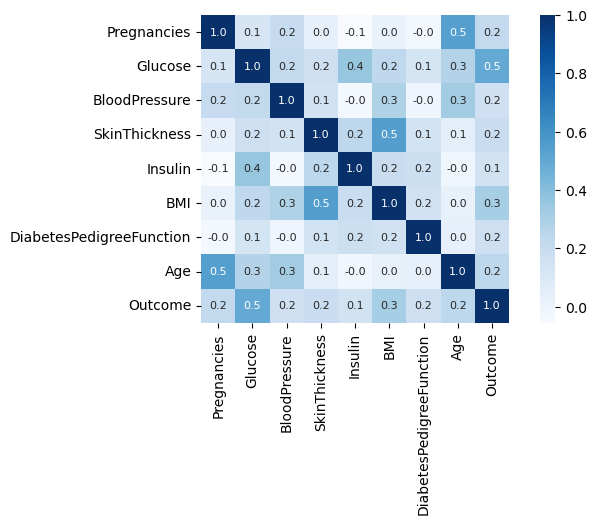

In [11]:
corr = df.corr()

# constructing a heatmap to nderstand the correlation

plt.figure(figsize=(8,4))

sns.heatmap(corr, cbar=True, square=True, fmt='.1f', annot=True, 

            annot_kws={'size':8}, cmap='Blues')

In [12]:
# KNN Model
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

# Create features and target

X = df.drop('Outcome', axis=1) 

y = df['Outcome']

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=0)



# Feature scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.fit_transform(X_test)

pipeline = Pipeline([

    ('scaler', StandardScaler()),

    ('knn', KNeighborsClassifier())

])



param_grid = {

    'knn__n_neighbors': [3, 5, 7, 9, 11, 13],

    'knn__weights': ['uniform', 'distance'],

    'knn__p': [1, 2]  # 1: Manhattan distance, 2: Euclidean distance

}

In [13]:
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train, y_train)



# Get best parameters and model accuracy

best_params = grid_search.best_params_

best_model = grid_search.best_estimator_

print("Best Parameters:", best_params)

Best Parameters: {'knn__n_neighbors': 13, 'knn__p': 1, 'knn__weights': 'uniform'}


In [14]:
from sklearn.metrics import accuracy_score



y_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print("Test Set Accuracy:", test_accuracy)

Test Set Accuracy: 0.8311688311688312
